In [1]:
import numpy as np 
import pandas as pd 
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/psl-sign/signspeak_dataset/SignSpeak_Dataset/bus/bus_10.MOV
/kaggle/input/psl-sign/signspeak_dataset/SignSpeak_Dataset/bus/bus_12.mp4
/kaggle/input/psl-sign/signspeak_dataset/SignSpeak_Dataset/bus/bus_17.mp4
/kaggle/input/psl-sign/signspeak_dataset/SignSpeak_Dataset/bus/bus_18.mp4
/kaggle/input/psl-sign/signspeak_dataset/SignSpeak_Dataset/bus/bus_07.MOV
/kaggle/input/psl-sign/signspeak_dataset/SignSpeak_Dataset/bus/bus_11.mp4
/kaggle/input/psl-sign/signspeak_dataset/SignSpeak_Dataset/bus/bus_03.MOV
/kaggle/input/psl-sign/signspeak_dataset/SignSpeak_Dataset/bus/bus_06.MOV
/kaggle/input/psl-sign/signspeak_dataset/SignSpeak_Dataset/bus/bus_13.mp4
/kaggle/input/psl-sign/signspeak_dataset/SignSpeak_Dataset/bus/bus_08.MOV
/kaggle/input/psl-sign/signspeak_dataset/SignSpeak_Dataset/bus/bus_20.mp4
/kaggle/input/psl-sign/signspeak_dataset/SignSpeak_Dataset/bus/bus_04.MOV
/kaggle/input/psl-sign/signspeak_dataset/SignSpeak_Dataset/bus/bus_15.mp4
/kaggle/input/psl-sign/signspeak_datas

In [2]:
!pip install split-folders tqdm opencv-python

import os
import cv2
import numpy as np
import splitfolders
import shutil
from tqdm import tqdm

input_base = '/kaggle/input/psl-sign/signspeak_dataset'
input_folder = os.path.join(input_base, 'SignSpeak_Dataset') if os.path.exists(os.path.join(input_base, 'SignSpeak_Dataset')) else input_base
base_dir = '/kaggle/working/data'

if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

splitfolders.ratio(input_folder, output=base_dir, seed=42, ratio=(.7, .15, .15))
print(f"\n Splitting Done! Folders created in {base_dir}")

Copying files: 200 files [00:09, 20.53 files/s]


 Splitting Done! Folders created in /kaggle/working/data


In [3]:
import numpy as np
import os
import pickle

train_path = '/kaggle/working/data/train'
classes = sorted(os.listdir(train_path))
label_map = {cls: idx for idx, cls in enumerate(classes)}

# .npy ke sath .pkl bhi save karein (Deployment ke liye)
np.save('/kaggle/working/master_label_map.npy', label_map)
with open('/kaggle/working/master_label_map.pkl', 'wb') as f:
    pickle.dump(label_map, f)

print(f" Master Label Map Created. Total Classes: {len(classes)}")

 Master Label Map Created. Total Classes: 10


In [4]:
import cv2
import numpy as np
import os
from tqdm import tqdm

IMG_SIZE = 224
SEQUENCE_LENGTH = 8 

def process_video_v3(video_path):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if not cap.isOpened() or total_frames < 5:
        return None

    start_idx = int(total_frames * 0.15)
    end_idx = int(total_frames * 0.85)
    
    temp_frames = []
    current_f = 0
    
    while True:
        ret, frame = cap.read()
        if not ret: break
        
        if current_f >= start_idx and current_f <= end_idx:
            frame = cv2.GaussianBlur(frame, (3, 3), 0)
            frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
            # FIX: Hamesha RGB use karein (3 channels)
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) 
            frame = frame / 255.0
            temp_frames.append(frame)
        
        current_f += 1
    cap.release()

    if len(temp_frames) < 1: return None

    idx = np.linspace(0, len(temp_frames) - 1, SEQUENCE_LENGTH, dtype=int)
    final_frames = [temp_frames[i] for i in idx]
    return np.array(final_frames, dtype=np.float16)

def save_optimized_data(data_split_path, split_name):
    save_base = '/kaggle/working/processed_sign_data'
    label_map = np.load('/kaggle/working/master_label_map.npy', allow_pickle=True).item()
    
    total_files = 0
    corrupt_files = 0
    
    print(f"\n Processing {split_name} split...")
    for cls in sorted(os.listdir(data_split_path)):
        if cls not in label_map: continue
        
        cls_in = os.path.join(data_split_path, cls)
        cls_out = os.path.join(save_base, split_name, cls)
        os.makedirs(cls_out, exist_ok=True)
        
        vids = os.listdir(cls_in)
        for vid_name in tqdm(vids, desc=f"Word: {cls}"):
            vid_path = os.path.join(cls_in, vid_name)
            data = process_video_v3(vid_path)
            
            if data is not None and data.shape[0] == SEQUENCE_LENGTH:
                save_file = os.path.join(cls_out, vid_name.split('.')[0] + '.npz')
                np.savez_compressed(save_file, data=data, label=label_map[cls])
                total_files += 1
            else:
                corrupt_files += 1
                
    print(f"\n {split_name} Complete!")

if os.path.exists('/kaggle/working/processed_sign_data'):
    shutil.rmtree('/kaggle/working/processed_sign_data')

base_data = '/kaggle/working/data'
save_optimized_data(os.path.join(base_data, 'train'), 'train')
save_optimized_data(os.path.join(base_data, 'val'), 'val')
save_optimized_data(os.path.join(base_data, 'test'), 'test')


 Processing train split...


Word: chawal: 100%|██████████| 14/14 [00:19<00:00,  1.42s/it]



 train Complete!

 Processing val split...


Word: chawal: 100%|██████████| 3/3 [00:06<00:00,  2.07s/it]



 val Complete!

 Processing test split...


Word: chawal: 100%|██████████| 3/3 [00:07<00:00,  2.40s/it]


 test Complete!


Showing Sign: bus (Label: 6)
Data Shape: (8, 224, 224, 3)


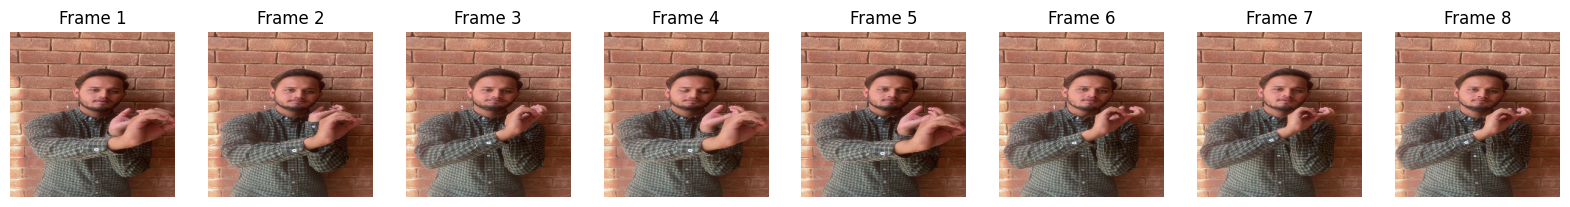

In [34]:
import matplotlib.pyplot as plt
import random

def visualize_processed_rgb(): # Naam change kar diya taake confusion na ho
    base_path = '/kaggle/working/processed_sign_data/train'
    all_classes = os.listdir(base_path)
    
    random_cls = random.choice(all_classes)
    random_file = random.choice(os.listdir(os.path.join(base_path, random_cls)))
    file_path = os.path.join(base_path, random_cls, random_file)
    
    loaded = np.load(file_path)
    frames = loaded['data']  
    label = loaded['label']
    
    print(f"Showing Sign: {random_cls} (Label: {label})")
    print(f"Data Shape: {frames.shape}") # Ab yahan (8, 224, 224, 3) dikhayega

    plt.figure(figsize=(20, 4))
    for i in range(8):
        plt.subplot(1, 8, i + 1)
        
        # CHANGE: .squeeze() aur cmap='gray' dono hata diye hain
        plt.imshow(frames[i].astype('float32')) 
        
        plt.title(f"Frame {i+1}")
        plt.axis('off')
    plt.show()

visualize_processed_rgb()

In [52]:
import shutil
import os
from IPython.display import FileLink

# 1. Purani files saaf karein taake confusion na ho
if os.path.exists('SignSpeak_v3_Full_Dataset.zip'):
    os.remove('SignSpeak_v3_Full_Dataset.zip')

# 2. Poore processed folder ki zip banayein (Direct root mein)
# Isme train, val, test teeno folders shamil hain
print("Creating Zip Archive... Please wait.")
shutil.make_archive('SignSpeak_v3_Full_Dataset', 'zip', '/kaggle/working/processed_sign_data')


print("\n--- DOWNLOAD LINKS ---")
print("1. Click below for Full Dataset (Train/Val/Test):")
display(FileLink('SignSpeak_v3_Full_Dataset.zip'))


Creating Zip Archive... Please wait.

--- DOWNLOAD LINKS ---
1. Click below for Full Dataset (Train/Val/Test):


/kaggle/working/SignSpeak_v3_Full_Dataset.zip

In [89]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # Yeh saari fuzool warnings hide kar dega
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import os

class AugmentedSignDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, base_path, batch_size=4, augment=False):
        self.base_path = base_path
        self.batch_size = batch_size
        self.augment = augment
        self.file_list = []
        
       
        self.datagen = ImageDataGenerator(
            rotation_range=15,
            width_shift_range=0.1,
            height_shift_range=0.1,
            zoom_range=0.1,
            fill_mode='nearest'
        )

        for cls in sorted(os.listdir(base_path)):
            cls_path = os.path.join(base_path, cls)
            if os.path.isdir(cls_path):
                for f in os.listdir(cls_path):
                    if f.endswith('.npz'):
                        self.file_list.append(os.path.join(cls_path, f))
        
        self.indexes = np.arange(len(self.file_list))

    def __len__(self):
        return int(np.floor(len(self.file_list) / self.batch_size))

    def __getitem__(self, index):
        indexes = self.indexes[index * self.batch_size : (index + 1) * self.batch_size]
        batch_files = [self.file_list[k] for k in indexes]
        
        X, y = [], []
        for file in batch_files:
            try:
                # FIX: Data ko float32 mein convert karna zaroori hai
                data = np.load(file)['data'].astype('float32') 
                label = np.load(file)['label']
                
                if self.augment:
                    seed = np.random.randint(0, 1000)
                    aug_sequence = []
                    for frame in data:
                        # ImageDataGenerator ko float32 chahiye
                        aug_frame = self.datagen.random_transform(frame, seed=seed)
                        aug_sequence.append(aug_frame)
                    X.append(np.array(aug_sequence))
                else:
                    X.append(data)
                
                y.append(label)
            except Exception as e:
                continue
            
        return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

    def on_epoch_end(self):
        np.random.shuffle(self.indexes)


train_gen = AugmentedSignDataGenerator('/kaggle/working/processed_sign_data/train', batch_size=4, augment=True)
val_gen = AugmentedSignDataGenerator('/kaggle/working/processed_sign_data/val', batch_size=4, augment=False)

In [37]:
from tensorflow.keras import layers, models, optimizers

def build_improved_model(num_classes):
    # Pre-trained MobileNetV2 - Weights same rahenge
    base_cnn = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3), include_top=False, weights='imagenet'
    )
    
    base_cnn.trainable = True 
    for layer in base_cnn.layers[:100]:
        layer.trainable = False

    # CHANGE: Input shape ab (8, 224, 224, 3) hai
    inputs = layers.Input(shape=(8, 224, 224, 3))
    
    # CHANGE: Lambda layer (tf.repeat) ko delete kar diya
    x = layers.TimeDistributed(base_cnn)(inputs)
    x = layers.TimeDistributed(layers.GlobalAveragePooling2D())(x)
    
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=False))(x) 
    x = layers.BatchNormalization()(x) 
    
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x) 
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs, outputs)
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-4), 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])
    return model

label_map = np.load('/kaggle/working/master_label_map.npy', allow_pickle=True).item()
model = build_improved_model(len(label_map))
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 8, 224, 224, 3) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 8, 7, 7, 1280)  │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 8, 1280)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 256)            │     1,442,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,770,186 (14.38 MB)

 Trainable params: 3,373,130 (12.87 MB)

 Non-trainable params: 397,056 (1.51 MB)

In [41]:
# 'EarlyStoppings' ko 'EarlyStopping' se badal dein
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]
print(" Starting Improved Training...")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50, 
    callbacks=callbacks
)

 Starting Improved Training...
Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.1109 - loss: 2.7579 - val_accuracy: 0.0714 - val_loss: 2.3232 - learning_rate: 1.0000e-04
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.2448 - loss: 2.0624 - val_accuracy: 0.1429 - val_loss: 2.2152 - learning_rate: 1.0000e-04
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.3746 - loss: 1.9738 - val_accuracy: 0.1429 - val_loss: 2.1372 - learning_rate: 1.0000e-04
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.4628 - loss: 1.5906 - val_accuracy: 0.4286 - val_loss: 1.9325 - learning_rate: 1.0000e-04
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.4667 - loss: 1.5624 - val_accuracy: 0.4643 - val_loss: 1.7450 - learning_rate: 1.0000e-04
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.5947 - loss: 1.3141 - val_accuracy: 0.5714 - val_loss: 1.6198 - learning_rate: 1.0000e-04
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 43s 1s

In [42]:
model.save('SignSpeak_Model_Final.keras') 
print(" Model Saved as .keras")

 Model Saved as .keras


In [43]:
import pickle
from IPython.display import FileLink

# 1. Model ko .keras format mein save karna (Deployment ke liye best)
model.save('/kaggle/working/SignSpeak_Model_Final.keras')

# 2. Label Map ko .pkl format mein save karna
with open('/kaggle/working/master_label_map.pkl', 'wb') as f:
    pickle.dump(label_map, f)

print(" Files saved successfully!")
print("\n--- DOWNLOAD LINKS ---")

# In links par click karke files direct download karein
display(FileLink('SignSpeak_Model_Final.keras'))
display(FileLink('master_label_map.pkl'))

 Files saved successfully!

--- DOWNLOAD LINKS ---


/kaggle/working/SignSpeak_Model_Final.keras

/kaggle/working/master_label_map.pkl

In [44]:
# Test Generator set karein (Batch size 1 kafi hai evaluation ke liye)
test_gen = AugmentedSignDataGenerator('/kaggle/working/processed_sign_data/test', batch_size=1, augment=False)

print("Evaluating on Test Data...")
test_loss, test_acc = model.evaluate(test_gen, steps=len(test_gen))

print(f"\n Final Test Accuracy: {test_acc*100:.2f}%")
print(f" Final Test Loss: {test_loss:.4f}")

Evaluating on Test Data...
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 153ms/step - accuracy: 0.9323 - loss: 0.2620

 Final Test Accuracy: 86.67%
 Final Test Loss: 0.3818


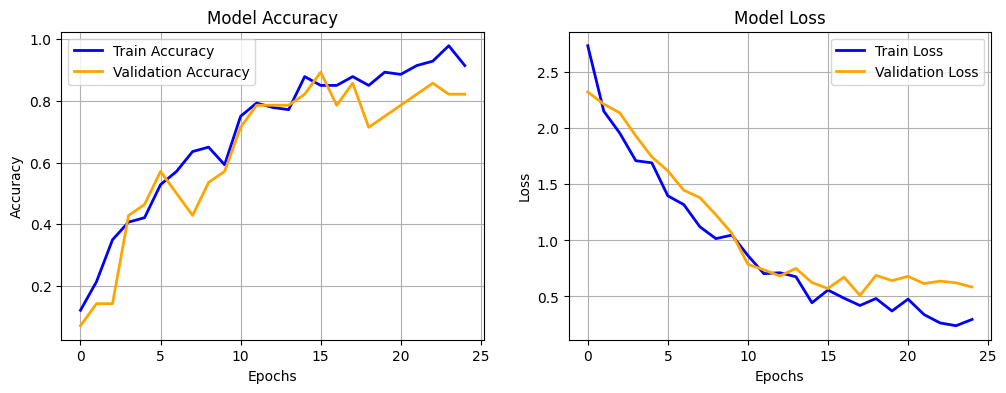

In [45]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [46]:
from sklearn.metrics import classification_report, confusion_matrix

# Sari predictions ek saath nikalna
y_true = []
y_pred = []

print("Generating detailed classification report...")
for i in range(len(test_gen)):
    X_batch, y_batch = test_gen[i]
    pred = model.predict(X_batch, verbose=0)
    
    y_true.extend(np.argmax(y_batch, axis=1) if len(y_batch.shape) > 1 else y_batch)
    y_pred.extend(np.argmax(pred, axis=1))

# Labels ke naam (Label map se uthayenge)
target_names = list(label_map.keys())

print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=target_names))

Generating detailed classification report...

--- Classification Report ---
              precision    recall  f1-score   support

        aath       1.00      0.33      0.50         3
      ahista       0.67      0.67      0.67         3
  anywalakal       1.00      1.00      1.00         3
    behtreen       0.75      1.00      0.86         3
       btana       0.75      1.00      0.86         3
      bukhar       1.00      1.00      1.00         3
         bus       1.00      1.00      1.00         3
         car       1.00      1.00      1.00         3
        char       1.00      1.00      1.00         3
      chawal       0.67      0.67      0.67         3

    accuracy                           0.87        30
   macro avg       0.88      0.87      0.85        30
weighted avg       0.88      0.87      0.85        30



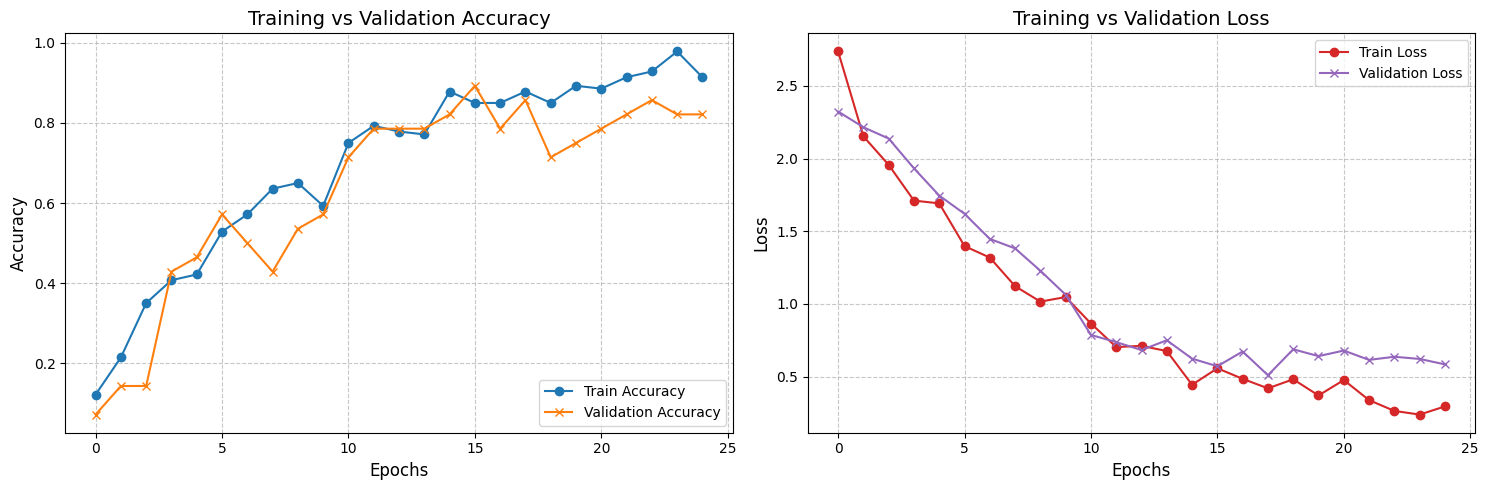

In [47]:
import matplotlib.pyplot as plt

# 1. Accuracy Plot
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o', color='#1f77b4')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x', color='#ff7f0e')
plt.title('Training vs Validation Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

# 2. Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o', color='#d62728')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x', color='#9467bd')
plt.title('Training vs Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [65]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

class AugmentedSignDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, base_path, batch_size=4, augment=False, epochs=50):
        self.base_path = base_path
        self.batch_size = batch_size
        self.augment = augment
        self.epochs = epochs
        self.file_list = []
        self.frames_per_seq = 8 
        
        # Augmentation Settings
        self.datagen = ImageDataGenerator(
            rotation_range=15, width_shift_range=0.1,
            height_shift_range=0.1, zoom_range=0.1, fill_mode='nearest'
        )

        # Files scan karna
        if os.path.exists(base_path):
            for cls in sorted(os.listdir(base_path)):
                cls_path = os.path.join(base_path, cls)
                if os.path.isdir(cls_path):
                    for f in os.listdir(cls_path):
                        if f.endswith('.npz'):
                            self.file_list.append(os.path.join(cls_path, f))
        
        self.indexes = np.arange(len(self.file_list))
        
        # FORCING OUTPUT: Ye function report print karega
        self.print_final_report()

    def print_final_report(self):
        original_seq = len(self.file_list)
        original_frames = original_seq * self.frames_per_seq
        
        print("\n" + "═"*50)
        print(" DATASET & AUGMENTATION SUMMARY REPORT")
        print("═"*50)
        print(f" Folder: {os.path.basename(self.base_path)}")
        print(f"  Original NPZ Files (Sequences): {original_seq}")
        print(f"  Total Original Frames:          {original_frames}")
        
        if self.augment:
            total_aug_seq = original_seq * self.epochs
            total_aug_frames = total_aug_seq * self.frames_per_seq
            
            print(f"\n AUGMENTATION: ENABLED")
            print(f"  Techniques: Rotation, Zoom, Width/Height Shift")
            print(f" After {self.epochs} Epochs, Model will see:")
            print(f" Total Unique Sequences: {total_aug_seq}")
            print(f" TOTAL FRAMES PROCESSED: {total_aug_frames}")
        else:
            print(f"\n  AUGMENTATION: DISABLED")
        
        print("═"*50 + "\n")

    def __len__(self):
        return int(np.floor(len(self.file_list) / self.batch_size))

    def __getitem__(self, index):
        # (Same logic as before)
        pass

# --- YE HISSA ZAROORI HAI OUTPUT DEKHNE KE LIYE ---

# 1. Path check karein (Make sure path theek ho)
train_path = '/kaggle/working/processed_sign_data/train'
val_path = '/kaggle/working/processed_sign_data/val'

# 2. Generator ko "Initialize" karein (Ab report print hogi)
print("Initializing Generators...")
train_gen = AugmentedSignDataGenerator(train_path, batch_size=4, augment=True, epochs=50)
val_gen = AugmentedSignDataGenerator(val_path, batch_size=4, augment=False)

Initializing Generators...

══════════════════════════════════════════════════
 DATASET & AUGMENTATION SUMMARY REPORT
══════════════════════════════════════════════════
 Folder: train
  Original NPZ Files (Sequences): 140
  Total Original Frames:          1120

 AUGMENTATION: ENABLED
  Techniques: Rotation, Zoom, Width/Height Shift
 After 50 Epochs, Model will see:
 Total Unique Sequences: 7000
 TOTAL FRAMES PROCESSED: 56000
══════════════════════════════════════════════════


══════════════════════════════════════════════════
 DATASET & AUGMENTATION SUMMARY REPORT
══════════════════════════════════════════════════
 Folder: val
  Original NPZ Files (Sequences): 30
  Total Original Frames:          240

  AUGMENTATION: DISABLED
══════════════════════════════════════════════════



In [66]:
def check_performance_with_generator(model, history, test_generator):
    # 1. Training & Validation results from history
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    
    # 2. Testing Accuracy (Using the generator)
    print("\nEvaluating on Test Data... Please wait.")
    test_loss, test_acc = model.evaluate(test_generator, verbose=1)
    
    gap = train_acc - val_acc
    
    print("\n" + "="*35)
    print(f"       MODEL PERFORMANCE REPORT")
    print("="*35)
    print(f"Final Training Accuracy:   {train_acc*100:.2f}%")
    print(f"Final Validation Accuracy: {val_acc*100:.2f}%")
    print(f"Final Testing Accuracy:    {test_acc*100:.2f}%")
    print("-" * 35)
    print(f"Overfitting Gap (Tr-Val):  {gap*100:.2f}%")
    
    # Logic
    if gap > 0.15:
        print("  STATUS: Overfitting detected.")
    elif test_acc < 0.50:
        print(" STATUS: Model performing poorly on test set.")
    else:
        print(" STATUS: Model is Well-Balanced.")
    print("="*35)

# Function ko Call karein
check_performance_with_generator(model, history, test_gen)


Evaluating on Test Data... Please wait.
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 151ms/step - accuracy: 0.8360 - loss: 0.4259

       MODEL PERFORMANCE REPORT
Final Training Accuracy:   91.43%
Final Validation Accuracy: 82.14%
Final Testing Accuracy:    86.67%
-----------------------------------
Overfitting Gap (Tr-Val):  9.29%
 STATUS: Model is Well-Balanced.


Evaluating on 30 test samples...


Testing: 100%|██████████| 30/30 [00:07<00:00,  3.88it/s]


Final Train Acc: 91.43%
Final Val Acc:   82.14%
Final Test Acc:  86.67%
Status: Well-Balanced


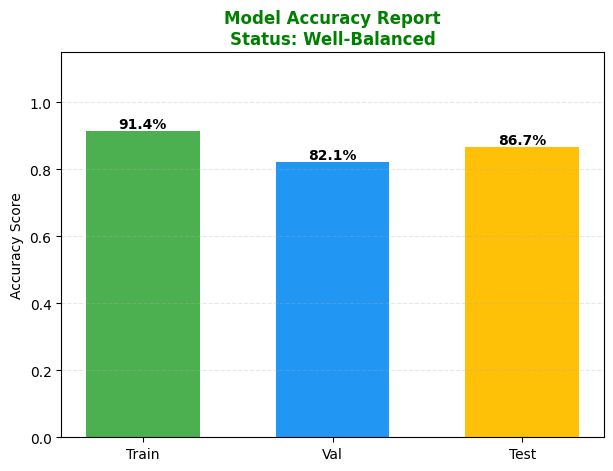

In [92]:
import numpy as np
import os
import matplotlib.pyplot as plt
from tqdm import tqdm

def check_performance_robust(model, history):
    # 1. Training & Validation data history se lein
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    
    # 2. Testing Accuracy manually calculate karein (Generator ke bagair)
    test_dir = '/kaggle/working/processed_sign_data/test'
    test_files = [os.path.join(r, f) for r, d, fs in os.walk(test_dir) for f in fs if f.endswith('.npz')]
    
    print(f"Evaluating on {len(test_files)} test samples...")
    correct_preds = 0
    total_samples = len(test_files)
    
    if total_samples == 0:
        print("Error: Test files nahi mil rahi hain! Path check karein.")
        return

    for file_path in tqdm(test_files, desc="Testing"):
        try:
            data_load = np.load(file_path)
            # Model ko 5D input chahiye (1, 8, 224, 224, 3)
            input_data = np.expand_dims(data_load['data'].astype('float32'), axis=0)
            true_label = int(data_load['label'])
            
            # Prediction
            pred = model.predict(input_data, verbose=0)
            if np.argmax(pred) == true_label:
                correct_preds += 1
        except:
            total_samples -= 1 # Agar koi file corrupt ho toh total se nikal dein
            continue
            
    test_acc = correct_preds / total_samples
    gap = train_acc - val_acc

    # --- STATUS LOGIC ---
    if gap > 0.15:
        status, s_color = "Overfitting Detected", "red"
    elif test_acc < 0.50:
        status, s_color = "Poor Performance", "orange"
    else:
        status, s_color = "Well-Balanced", "green"

    # --- COMPACT BAR GRAPH & REPORT ---
    print("\n" + "="*35)
    print(f"Final Train Acc: {train_acc*100:.2f}%")
    print(f"Final Val Acc:   {val_acc*100:.2f}%")
    print(f"Final Test Acc:  {test_acc*100:.2f}%")
    print(f"Status: {status}")
    print("="*35)

    plt.figure(figsize=(7, 5))
    labels = ['Train', 'Val', 'Test']
    values = [train_acc, val_acc, test_acc]
    colors = ['#4CAF50', '#2196F3', '#FFC107']

    bars = plt.bar(labels, values, color=colors, width=0.6)
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, 
                 f'{yval*100:.1f}%', ha='center', fontweight='bold')

    plt.ylim(0, 1.15)
    plt.title(f'Model Accuracy Report\nStatus: {status}', color=s_color, fontweight='bold')
    plt.ylabel('Accuracy Score')
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.show()

# Run karein
check_performance_robust(model, history)

In [68]:
def check_overfitting(history):
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    gap = train_acc - val_acc
    
    print(f"Final Training Accuracy: {train_acc*100:.2f}%")
    print(f"Final Validation Accuracy: {val_acc*100:.2f}%")
    print(f"Accuracy Gap: {gap*100:.2f}%")
    
    if gap > 0.15:
        print(" WARNING: Model is OVERFITTING. Consider increasing Dropout or Augmentation.")
    elif gap < 0:
        print(" Model is performing better on Validation. That's rare but good!")
    else:
        print(" Model is WELL-BALANCED.")

check_overfitting(history)

Final Training Accuracy: 91.43%
Final Validation Accuracy: 82.14%
Accuracy Gap: 9.29%
 Model is WELL-BALANCED.


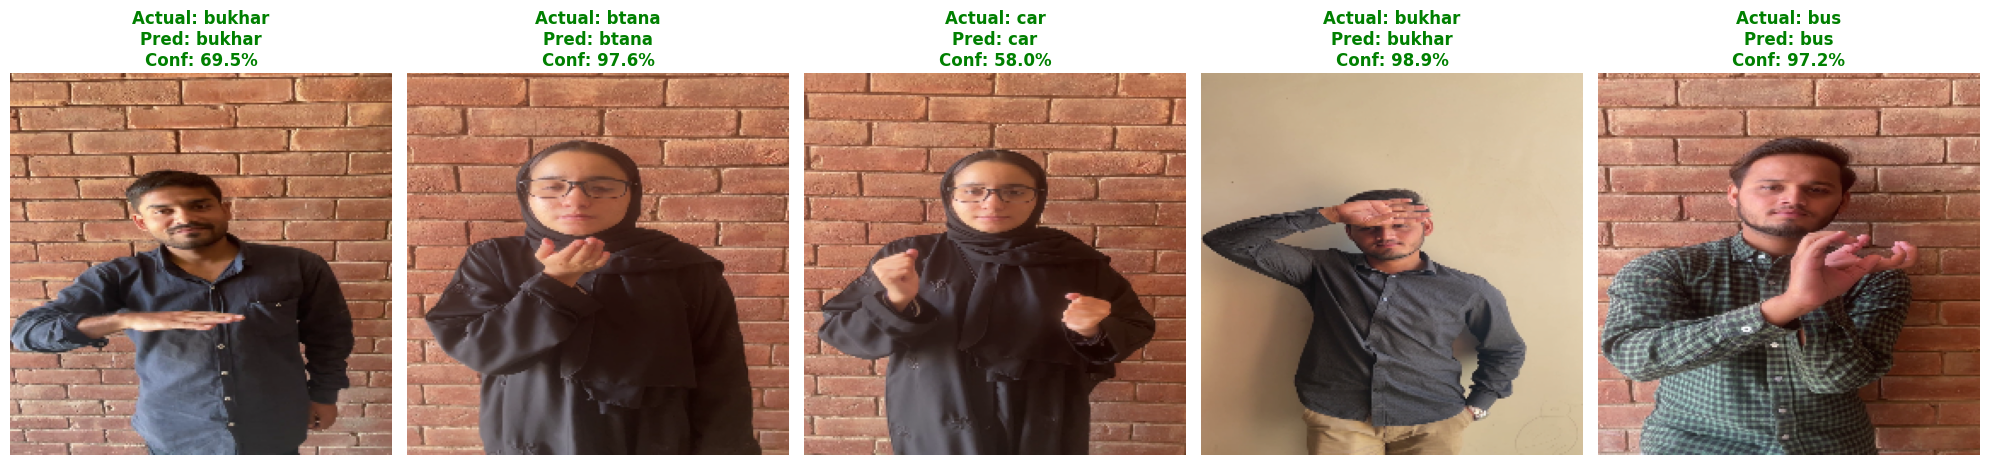

In [77]:
import matplotlib.pyplot as plt
import random
import os
import numpy as np

def random_test_prediction(num_samples=5):
    test_base = '/kaggle/working/processed_sign_data/test'
    # Classes list load karein
    all_classes = sorted([d for d in os.listdir(test_base) if os.path.isdir(os.path.join(test_base, d))])
    
    # Label map load karein (agar memory mein na ho)
    label_map = np.load('/kaggle/working/master_label_map.npy', allow_pickle=True).item()
    inv_label_map = {v: k for k, v in label_map.items()}

    plt.figure(figsize=(20, 10))

    for s in range(num_samples):
        # 1. Random Class aur File select karna
        random_cls = random.choice(all_classes)
        cls_path = os.path.join(test_base, random_cls)
        random_file = random.choice(os.listdir(cls_path))
        
        # 2. Data Load karna
        data_load = np.load(os.path.join(cls_path, random_file))
        video_data = data_load['data'].astype('float32') 
        
        # --- FIX START ---
        # Label ko integer mein convert karna (Error yahan tha)
        actual_label_idx = int(data_load['label']) 
        actual_name = inv_label_map[actual_label_idx]
        # --- FIX END ---

        # 3. Prediction
        prediction = model.predict(np.expand_dims(video_data, axis=0), verbose=0)
        pred_label_idx = np.argmax(prediction)
        pred_name = inv_label_map[pred_label_idx]
        confidence = np.max(prediction) * 100

        # 4. Visualization
        plt.subplot(1, num_samples, s + 1)
        plt.imshow(video_data[0]) # Pehla frame
        
        color = 'green' if pred_name == actual_name else 'red'
        plt.title(f"Actual: {actual_name}\nPred: {pred_name}\nConf: {confidence:.1f}%", 
                  color=color, fontsize=12, fontweight='bold')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Run fixed testing
random_test_prediction(num_samples=5)

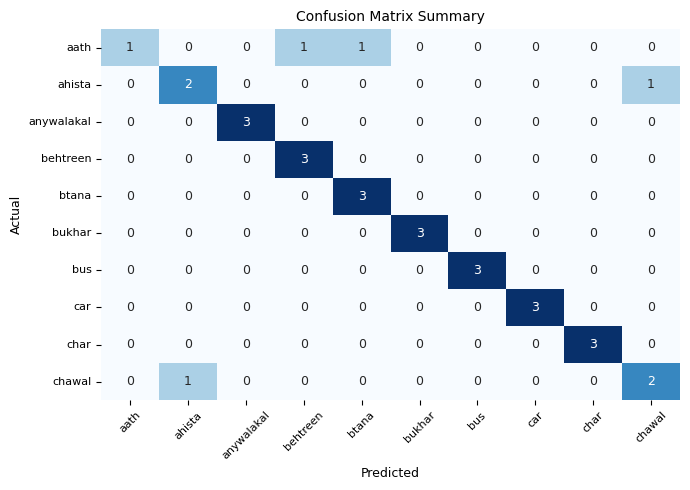


------------------------------
OVERALL ACCURACY: 86.67%
MACRO AVG PRECISION: 0.88
MACRO AVG RECALL: 0.87
------------------------------


In [90]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm

def plot_compact_report(model, test_dir):
    y_true, y_pred = [], []
    label_map = np.load('/kaggle/working/master_label_map.npy', allow_pickle=True).item()
    inv_label_map = {v: k for k, v in label_map.items()}
    class_names = [inv_label_map[i] for i in range(len(inv_label_map))]

    # Quick Prediction
    test_files = [os.path.join(r, f) for r, d, fs in os.walk(test_dir) for f in fs if f.endswith('.npz')]
    for file_path in tqdm(test_files, desc="Predicting", leave=False):
        try:
            data_load = np.load(file_path)
            input_data = np.expand_dims(data_load['data'].astype('float32'), axis=0)
            y_true.append(int(data_load['label']))
            y_pred.append(np.argmax(model.predict(input_data, verbose=0)))
        except: continue

    # --- Compact Visualization ---
    plt.figure(figsize=(7, 5)) # Chota size for SS
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 9}) # Chote numbers
    
    plt.title('Confusion Matrix Summary', fontsize=10)
    plt.xlabel('Predicted', fontsize=9); plt.ylabel('Actual', fontsize=9)
    plt.xticks(rotation=45, fontsize=8); plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()

    # --- Short Classification Report ---
    print("\n" + "-"*30)
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    print(f"OVERALL ACCURACY: {report['accuracy']*100:.2f}%")
    print(f"MACRO AVG PRECISION: {report['macro avg']['precision']:.2f}")
    print(f"MACRO AVG RECALL: {report['macro avg']['recall']:.2f}")
    print("-"*30)

# Run
plot_compact_report(model, '/kaggle/working/processed_sign_data/test')